# Neural Network Sentiment Analysis (NLP)
**Dataset:** Amazon, Yelp, and IMDb Sentiment Dataset (Kotzias et al., KDD 2015)  
**Goal:** Binary sentiment classification using deep learning and NLP techniques.

## 0. Install & Import Dependencies

In [778]:
# Install required packages if not already present
# !pip install nltk tensorflow scikit-learn pandas numpy matplotlib seaborn

import os
import re
import string
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.regularizers import l2
import pickle

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('All libraries loaded successfully.')

TensorFlow version: 2.19.1
All libraries loaded successfully.


---
## Part A – Problem Definition
**Research Question:** Can a Bidirectional LSTM neural network, trained on labeled customer and user reviews from Amazon, Yelp, and IMDb, accurately classify the sentiment of unseen text as positive or negative?

**Objective:** Train a binary sentiment classifier achieving at least 85% accuracy on the held-out test set using NLP preprocessing and a Bidirectional LSTM architecture.

**Selected Network:** Bidirectional LSTM (Long Short-Term Memory)  
**Justification:** LSTMs capture sequential dependencies in text; bidirectional processing reads context from both directions, improving sentiment detection in complex sentence structures.

---
## Part B – Data Preparation
### B1. Load Datasets & Exploratory Data Analysis (EDA)

In [779]:
# ---------------------------------------------------------------
# Load the three TSV files (tab-separated, no header)
# Expected columns: sentence (text) | label (0 or 1)
# Dataset files must be under data/ folder
# ---------------------------------------------------------------

def load_dataset(filepath, source_name):
    """Load a tab-separated sentiment file and tag the source."""
    df = pd.read_csv(filepath, sep='\t', header=None, names=['text', 'label'],
                     on_bad_lines='skip', engine='python')
    df['source'] = source_name
    return df

# File locations
amazon_df = load_dataset('data/Amazon_Dataset.txt',     'amazon')
yelp_df   = load_dataset('data/Yelp_Dataset.txt',         'yelp')
imdb_df   = load_dataset('data/IMDB_Dataset.txt',         'imdb')

# Combine all three datasets into one
df = pd.concat([amazon_df, yelp_df, imdb_df], ignore_index=True)

print("amazon shape: ", amazon_df.shape)
print("yelp shape: ", yelp_df.shape)
print("imdb shape", imdb_df.shape)
print()
print('Combined dataset shape:', df.shape)
print(df.head())

amazon shape:  (1000, 3)
yelp shape:  (1000, 3)
imdb shape (743, 3)

Combined dataset shape: (2743, 3)
                                                text  label  source
0  So there is no way for me to plug it in here i...      0  amazon
1                        Good case, Excellent value.      1  amazon
2                             Great for the jawbone.      1  amazon
3  Tied to charger for conversations lasting more...      0  amazon
4                                  The mic is great.      1  amazon


In [780]:
# printing the distribution of positive and negative sentences in each dataset
print("amazon label distribution: ")
print(amazon_df["label"].value_counts().sort_index(), "\n")

print("yelp label distribution: ")
print(yelp_df["label"].value_counts().sort_index(), "\n")

print("imdb label distribution: ")
print(imdb_df["label"].value_counts().sort_index(), "\n")

amazon label distribution: 
label
0    500
1    500
Name: count, dtype: int64 

yelp label distribution: 
label
0    500
1    500
Name: count, dtype: int64 

imdb label distribution: 
label
0    359
1    384
Name: count, dtype: int64 



In [781]:
# Basic dataset overview
print('=== Dataset Info ===')
print(df.info())
print('\n=== Label Distribution ===')
print(df['label'].value_counts())
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2743 entries, 0 to 2742
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2743 non-null   str  
 1   label   2743 non-null   int64
 2   source  2743 non-null   str  
dtypes: int64(1), str(2)
memory usage: 64.4 KB
None

=== Label Distribution ===
label
1    1384
0    1359
Name: count, dtype: int64

=== Missing Values ===
text      0
label     0
source    0
dtype: int64


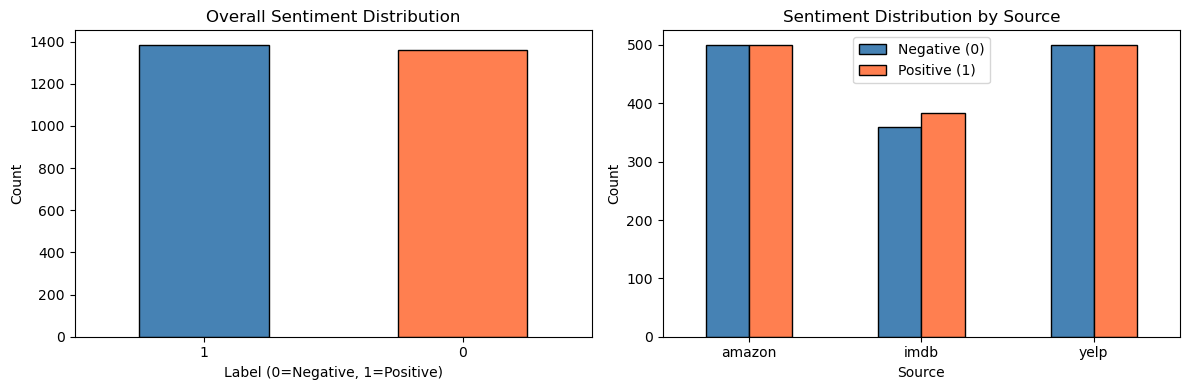

[INFO] Figure saved to figures/eda_label_distribution.png


In [782]:
os.makedirs("figures", exist_ok=True)

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall label distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Overall Sentiment Distribution')
axes[0].set_xlabel('Label (0=Negative, 1=Positive)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Per-source distribution
df.groupby(['source', 'label']).size().unstack().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'coral'], edgecolor='black')
axes[1].set_title('Sentiment Distribution by Source')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Count')
axes[1].legend(['Negative (0)', 'Positive (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('figures/eda_label_distribution.png', dpi=150)
plt.show()
print('[INFO] Figure saved to figures/eda_label_distribution.png')

=== Review Length Statistics (words) ===
count    2743.000000
mean       11.734962
std         7.763939
min         1.000000
25%         6.000000
50%        10.000000
75%        16.000000
max        71.000000
Name: text_length, dtype: float64


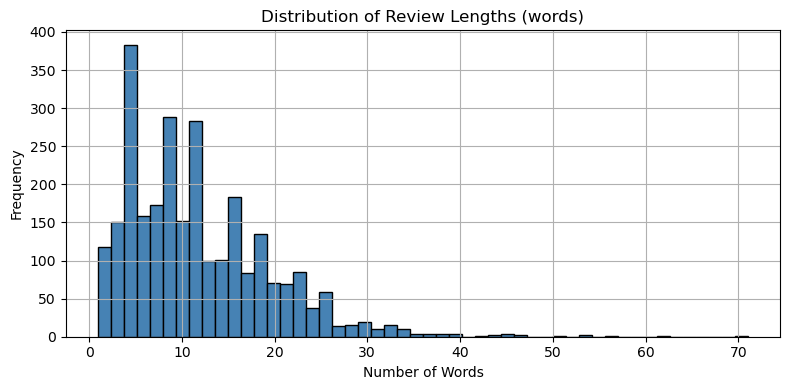

[INFO] Figure saved to figures/eda_review_lengths.png


In [783]:
# Review length analysis
df['text_length'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print('=== Review Length Statistics (words) ===')
print(df['text_length'].describe())

plt.figure(figsize=(8, 4))
df['text_length'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Review Lengths (words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Figures/eda_review_lengths.png', dpi=150)
plt.show()
print('[INFO] Figure saved to figures/eda_review_lengths.png')

In [784]:
# EDA: Detect unusual / non-text characters (emojis, non-ASCII, non-English)

# Non-ASCII character detection
def has_non_ascii(text):
    return bool(re.search(r'[^\x00-\x7F]', str(text)))

# Simple emoji detection using unicode ranges
def has_emoji(text):
    emoji_pattern = re.compile(
        '['
        u'\U0001F600-\U0001F64F'
        u'\U0001F300-\U0001F5FF'
        u'\U0001F680-\U0001F6FF'
        u'\U0001F1E0-\U0001F1FF'
        u'\U00002702-\U000027B0'
        u'\U000024C2-\U0001F251'
        ']+', flags=re.UNICODE)
    return bool(emoji_pattern.search(str(text)))

df['has_non_ascii'] = df['text'].apply(has_non_ascii)
df['has_emoji']     = df['text'].apply(has_emoji)

print('Reviews with non-ASCII characters:', df['has_non_ascii'].sum())
print('Reviews with emoji:', df['has_emoji'].sum())

# Show examples
print('\nExamples with non-ASCII characters:')
print(df[df['has_non_ascii']]['text'].head(5).to_string())

Reviews with non-ASCII characters: 15
Reviews with emoji: 0

Examples with non-ASCII characters:
1150    My fiancé and I came in the middle of the day ...
1598    I really enjoyed Crema Café before they expand...
1823           The crêpe was delicate and thin and moist.
1915    The only thing I wasn't too crazy about was th...
2018    It's practically perfect in all of them  a tr...


In [785]:
# EDA: Pre-processing vocabulary size (raw)
from collections import Counter

all_tokens_raw = ' '.join(df['text'].astype(str).tolist()).lower().split()
raw_vocab = Counter(all_tokens_raw)

print(f'Raw vocabulary size (unique tokens): {len(raw_vocab)}')
print(f'Total tokens: {len(all_tokens_raw)}')
print('\nTop 20 most frequent tokens (raw):')
print(raw_vocab.most_common(20))

Raw vocabulary size (unique tokens): 6802
Total tokens: 32189

Top 20 most frequent tokens (raw):
[('the', 1719), ('and', 1044), ('i', 819), ('a', 782), ('is', 661), ('to', 612), ('this', 561), ('was', 524), ('of', 520), ('it', 500), ('in', 345), ('for', 307), ('not', 281), ('that', 261), ('with', 249), ('my', 240), ('very', 224), ('on', 192), ('you', 181), ('but', 173)]


### B2. Text Preprocessing – Noise Reduction

In [786]:
# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Emoji regex pattern
EMOJI_PATTERN = re.compile(
    '['
    u'\U0001F600-\U0001F64F'
    u'\U0001F300-\U0001F5FF'
    u'\U0001F680-\U0001F6FF'
    u'\U0001F1E0-\U0001F1FF'
    u'\U00002702-\U000027B0'
    u'\U000024C2-\U0001F251'
    ']+', flags=re.UNICODE)

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    1. Lowercase
    2. Remove emojis
    3. Remove non-ASCII / non-English characters
    4. Remove or normalize excess punctuation
    5. Remove unnecessary numeric values
    6. Tokenize
    7. Remove stopwords
    8. Lemmatize
    """
    # Step 1 – Lowercase
    text = str(text).lower()

    # Step 2 – Remove emojis
    text = EMOJI_PATTERN.sub('', text)

    # Step 3 – Remove non-ASCII / non-English characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Step 4 – Remove or normalize excess punctuation
    # Keep single punctuation; collapse repeated punctuation (e.g., '!!!' → ' ')
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 5 – Remove unnecessary numeric values (standalone numbers)
    text = re.sub(r'\b\d+\b', '', text)

    # Step 6 – Tokenize (word_tokenize after basic clean)
    tokens = word_tokenize(text)

    # Step 7 – Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # Step 8 – Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

# Drop empty rows that result from preprocessing
df = df[df['clean_text'].str.strip() != ''].copy()

# Drop duplicate rows
before_dedup = len(df)
df = df.drop_duplicates(subset=['clean_text', 'label']).copy()
print(f'Rows removed as duplicates: {before_dedup - len(df)}')
print(f'Dataset size after preprocessing: {len(df)}')

# Reset index
df = df.reset_index(drop=True)

# Show before / after example
print('\n--- Before preprocessing ---')
print(df['text'].iloc[0])
print('--- After preprocessing ---')
print(df['clean_text'].iloc[0])

Rows removed as duplicates: 68
Dataset size after preprocessing: 2672

--- Before preprocessing ---
So there is no way for me to plug it in here in the US unless I go by a converter.
--- After preprocessing ---
way plug u unless go converter


In [787]:
# Post-preprocessing vocabulary size
all_tokens_clean = ' '.join(df['clean_text'].tolist()).split()
clean_vocab = Counter(all_tokens_clean)

print(f'Clean vocabulary size (unique tokens): {len(clean_vocab)}')
print(f'Vocabulary reduction: {len(raw_vocab)} → {len(clean_vocab)} tokens')
print('\nTop 20 most frequent tokens (clean):')
print(clean_vocab.most_common(20))

Clean vocabulary size (unique tokens): 4263
Vocabulary reduction: 6802 → 4263 tokens

Top 20 most frequent tokens (clean):
[('good', 214), ('great', 183), ('phone', 169), ('movie', 157), ('film', 140), ('food', 125), ('one', 122), ('time', 122), ('place', 120), ('like', 114), ('service', 110), ('work', 97), ('really', 91), ('bad', 90), ('well', 87), ('would', 78), ('best', 70), ('also', 70), ('back', 69), ('get', 67)]


### B3. Tokenization

In [788]:
# ---------------------------------------------------------------
# B3 – Tokenization using Keras Tokenizer
#
# VOCAB_SIZE is set to match the actual fitted vocabulary size rather
# than an arbitrary cap of 10,000. The cleaned corpus contains only
# 4,264 unique tokens. A cap of 10,000 would have no effect on this
# dataset (the vocab never reaches that ceiling) but would allocate a
# larger-than-necessary Embedding weight matrix with thousands of empty
# unused slots. Setting VOCAB_SIZE to the true fitted vocabulary size
# is more principled and memory-efficient.
#
# num_words in Keras Tokenizer keeps the top-N words by frequency.
# Since we set it equal to the full vocabulary, all tokens are retained.
# OOV_TOKEN '<OOV>' is assigned index 1 to handle unseen words at
# inference time without crashing.
# ---------------------------------------------------------------

OOV_TOKEN = '<OOV>'

# Step 1: probe-fit with no cap to discover the true vocabulary size
_probe_tok = Tokenizer(oov_token=OOV_TOKEN)
_probe_tok.fit_on_texts(df['clean_text'])
ACTUAL_VOCAB_SIZE = len(_probe_tok.word_index)  # 4264 for this dataset
VOCAB_SIZE = ACTUAL_VOCAB_SIZE

print(f'[INFO] Actual fitted vocabulary size: {ACTUAL_VOCAB_SIZE}')
print(f'[INFO] VOCAB_SIZE set to: {VOCAB_SIZE}')
print('[INFO] Full vocabulary retained – no artificial cap applied.')

# Step 2: fit the final tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])

example_idx = 0
print('\n=== Tokenization Example ===')
print(f'Original text:         {df["text"].iloc[example_idx]}')
print(f'Preprocessed text:     {df["clean_text"].iloc[example_idx]}')
print(f'Tokenized (integers):  {sequences[example_idx]}')
print(f'\nVocabulary size (fitted): {len(tokenizer.word_index)}')
print(f'Vocabulary size used:     {VOCAB_SIZE}')


[INFO] Actual fitted vocabulary size: 4264
[INFO] VOCAB_SIZE set to: 4264
[INFO] Full vocabulary retained – no artificial cap applied.

=== Tokenization Example ===
Original text:         So there is no way for me to plug it in here in the US unless I go by a converter.
Preprocessed text:     way plug u unless go converter
Tokenized (integers):  [44, 219, 88, 412, 25, 1868]

Vocabulary size (fitted): 4264
Vocabulary size used:     4264


### B4. Vectorization (Embedding)

In [789]:
# ---------------------------------------------------------------
# B4 – Vectorization / Sequence Length Analysis
#
# We use integer-indexed sequences as inputs to a trainable
# Embedding layer (dense word vectors, one per word index).
#
# EMBEDDING_DIM: each word is represented as a 64-dimensional
#   dense vector (common for small-to-medium NLP tasks).
#
# MAX_LEN: chosen to cover ≥95% of review lengths to minimize
#   information loss while keeping padding overhead low.
# ---------------------------------------------------------------

EMBEDDING_DIM = 64

# Statistical justification for MAX_LEN
seq_lengths = np.array([len(s) for s in sequences])
p50  = int(np.percentile(seq_lengths, 50))
p90  = int(np.percentile(seq_lengths, 90))
p95  = int(np.percentile(seq_lengths, 95))
p99  = int(np.percentile(seq_lengths, 99))
pmax = int(np.max(seq_lengths))

print('=== Sequence Length Percentiles (after preprocessing) ===')
print(f'50th percentile: {p50}')
print(f'90th percentile: {p90}')
print(f'95th percentile: {p95}')
print(f'99th percentile: {p99}')
print(f'Maximum:         {pmax}')

# Set MAX_LEN to 95th percentile to balance coverage vs. padding waste
MAX_LEN = p95
print(f'\nSelected MAX_LEN (95th percentile): {MAX_LEN}')
print(f'Embedding dimension (EMBEDDING_DIM): {EMBEDDING_DIM}')

# Show one example sequence (the vectorized form used as model input)
print('\n=== Vectorized Sequence Example (before padding) ===')
print(f'Review #{example_idx}: {sequences[example_idx]}')

=== Sequence Length Percentiles (after preprocessing) ===
50th percentile: 5
90th percentile: 11
95th percentile: 13
99th percentile: 20
Maximum:         44

Selected MAX_LEN (95th percentile): 13
Embedding dimension (EMBEDDING_DIM): 64

=== Vectorized Sequence Example (before padding) ===
Review #0: [44, 219, 88, 412, 25, 1868]


### B5. Sequence Padding


In [790]:
# ---------------------------------------------------------------
# B5 – Padding
#
# pad_sequences ensures all sequences have the same length.
#   padding='post'  → zeros appended AFTER the sequence
#   truncating='post' → long sequences are cut from the end
# Post-padding is preferred for RNN-family networks so the
# meaningful tokens are processed first.
# ---------------------------------------------------------------

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print('=== Padding Example ===')
print(f'Unpadded sequence:  {sequences[example_idx]}')
print(f'Padded sequence:    {X[example_idx]}')
print(f'\nAll sequences shape after padding: {X.shape}')
print(f'Labels shape: {y.shape}')

=== Padding Example ===
Unpadded sequence:  [44, 219, 88, 412, 25, 1868]
Padded sequence:    [  44  219   88  412   25 1868    0    0    0    0    0    0    0]

All sequences shape after padding: (2672, 13)
Labels shape: (2672,)


### B6. Train / Validation / Test Split

In [791]:
# ---------------------------------------------------------------
# B6 – Train / Validation / Test Split
#   70% Train | 15% Validation | 15% Test
# Stratified to preserve class balance in each split.
# ---------------------------------------------------------------

# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)

# Second split: 15% val, 15% test (50/50 of the 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

total = len(X)
print('=== Data Split Summary ===')
print(f'Total samples  : {total}')
print(f'Training set   : {len(X_train)} ({len(X_train)/total:.1%})')
print(f'Validation set : {len(X_val)}  ({len(X_val)/total:.1%})')
print(f'Test set       : {len(X_test)}  ({len(X_test)/total:.1%})')
print(f'\nSplit ratios — Train:Val:Test = 70:15:15')

=== Data Split Summary ===
Total samples  : 2672
Training set   : 1870 (70.0%)
Validation set : 401  (15.0%)
Test set       : 401  (15.0%)

Split ratios — Train:Val:Test = 70:15:15


In [792]:
# ---------------------------------------------------------------
# F2 – Save the fully processed dataset as a single .pkl file
#
# Placed here: right after preprocessing + splitting, before training.
# This captures the preprocessing artifact independently of model training.
#
# REPRODUCIBILITY / OVERWRITE LOGIC:
#   If file exists → compare X_padded and y_labels element-by-element.
#   [APPROVED] → identical, no overwrite needed.
#   [WARNING]  → content differs, file is overwritten.
# ---------------------------------------------------------------

DATASET_PATH = 'output/processed_dataset.pkl'
os.makedirs('output', exist_ok=True)

processed_data = {
    'X_padded':      X,
    'y_labels':      y,
    'X_train':       X_train,
    'X_val':         X_val,
    'X_test':        X_test,
    'y_train':       y_train,
    'y_val':         y_val,
    'y_test':        y_test,
    'clean_texts':   df['clean_text'].values,
    'sequences':     sequences,
    'vocab_size':    VOCAB_SIZE,
    'max_len':       MAX_LEN,
    'embedding_dim': EMBEDDING_DIM
}

if os.path.exists(DATASET_PATH):
    print(f'[INFO] Existing dataset found at {DATASET_PATH}. Comparing...')
    with open(DATASET_PATH, 'rb') as f_in:
        existing_data = pickle.load(f_in)

    x_match = np.array_equal(existing_data['X_padded'], processed_data['X_padded'])
    y_match  = np.array_equal(existing_data['y_labels'], processed_data['y_labels'])

    if x_match and y_match:
        print('[APPROVED] Saved dataset matches current pipeline output.')
        print('[INFO] Reproducibility confirmed – no overwrite performed.')
    else:
        print('[WARNING] Dataset differs from saved version. Overwriting...')
        with open(DATASET_PATH, 'wb') as f_out:
            pickle.dump(processed_data, f_out)
        print(f'[INFO] Dataset overwritten at {DATASET_PATH}')
else:
    with open(DATASET_PATH, 'wb') as f_out:
        pickle.dump(processed_data, f_out)
    print(f'[INFO] Processed dataset saved to {DATASET_PATH}')


[INFO] Existing dataset found at output/processed_dataset.pkl. Comparing...
[APPROVED] Saved dataset matches current pipeline output.
[INFO] Reproducibility confirmed – no overwrite performed.


---
## Part C – Model Design
### C1. Build and Summarize the Model

In [793]:
# ---------------------------------------------------------------
# C1 – Model Architecture: Bidirectional LSTM
#
# MODEL EXISTENCE CHECK:
#   If output/best_model.keras and output/tokenizer.pkl exist,
#   load them and set SKIP_TRAINING = True. Training, saving, and
#   the model-save cell are all skipped automatically.
#   Training history is also loaded from output/history.pkl if present,
#   so training curves can be plotted on every run.
#
# model.summary():
#   Keras defers weight allocation until the first forward pass.
#   model.build() forces immediate allocation so model.summary()
#   reports real parameter counts.
# ---------------------------------------------------------------

import logging
MODEL_PATH     = 'output/best_model.keras'
TOKENIZER_PATH = 'output/tokenizer.pkl'
HISTORY_PATH   = 'output/history.pkl'

os.makedirs('output',  exist_ok=True)

if os.path.exists(MODEL_PATH) and os.path.exists(TOKENIZER_PATH):
    print(f'[INFO] Saved model found at {MODEL_PATH}')
    print('[INFO] Loading model from disk. Training will be skipped.')
    model = load_model(MODEL_PATH)
    with open(TOKENIZER_PATH, 'rb') as f:
        tokenizer = pickle.load(f)
    SKIP_TRAINING = True

    # Load history so training curves are always available
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, 'rb') as f:
            history_dict = pickle.load(f)
        print(f'[INFO] Training history loaded from {HISTORY_PATH}')
    else:
        history_dict = None
        print('[INFO] No saved history found – training curves unavailable.')

    print('[INFO] Model and tokenizer loaded successfully.')

else:
    print('[INFO] No saved model found. Building new model for training...')
    SKIP_TRAINING = False
    history_dict  = None

    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE,
                  output_dim=EMBEDDING_DIM,
                  input_length=MAX_LEN,
                  name='embedding'),
        Bidirectional(LSTM(8, return_sequences=False,
                           kernel_regularizer=l2(1e-3)),
                      name='bidirectional_lstm'),
        Dropout(0.3, name='dropout_1'),
        Dense(2, activation='relu',
              kernel_regularizer=l2(1e-3),
              name='dense_hidden'),
        Dropout(0.3, name='dropout_2'),
        Dense(1, activation='sigmoid', name='output')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )

# Force weight allocation before summary so params are not shown as 0
model.build(input_shape=(None, MAX_LEN))

print('\n=== Model Summary ===')
model.summary()


[INFO] Saved model found at output/best_model.keras
[INFO] Loading model from disk. Training will be skipped.
[INFO] Training history loaded from output/history.pkl
[INFO] Model and tokenizer loaded successfully.

=== Model Summary ===


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 13, 64)              │         272,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_lstm (Bidirectional)   │ (None, 16)                  │           4,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_hidden (Dense)                 │ (None, 2)                   │              34 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 832,817 (3.18 MB)

 Trainable params: 277,605 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 555,212 (2.12 MB)

---
## Part D – Training & Evaluation

In [794]:
# ---------------------------------------------------------------
# D – Training + Immediate Artifact Save
#
# If a saved model was loaded in C1, this cell is skipped entirely.
# If training runs, three artifacts are saved immediately after:
#   output/best_model.keras  – best model weights (from ModelCheckpoint)
#   output/tokenizer.pkl     – fitted tokenizer
#   output/history.pkl       – training history dict for curve plotting
# ---------------------------------------------------------------

BATCH_SIZE = 32
EPOCHS     = 20

if SKIP_TRAINING:
    print('[INFO] SKIP_TRAINING=True – model loaded from disk. Training skipped.')
    print('[INFO] Using loaded model for all downstream evaluation cells.')

else:
    print('[INFO] Starting training...')

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=2,
        restore_best_weights=True,
        verbose=1
    )
    checkpoint = ModelCheckpoint(
        MODEL_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, checkpoint],
        verbose=1
    )
    print('Training complete.')

    # ── Save model ──────────────────────────────────────────────────────
    # ModelCheckpoint saved the best epoch weights during training.
    # We also do a final explicit save here for completeness.
    model.save(MODEL_PATH)
    print(f'[INFO] Model saved to {MODEL_PATH}')

    # ── Save tokenizer ───────────────────────────────────────────────────
    with open(TOKENIZER_PATH, 'wb') as f:
        pickle.dump(tokenizer, f)
    print(f'[INFO] Tokenizer saved to {TOKENIZER_PATH}')

    # ── Save training history ────────────────────────────────────────────
    # Stored as a plain dict (history.history) so it loads without Keras.
    # Enables training curve plots on every future run even when
    # SKIP_TRAINING=True and no training happens this session.
    history_dict = history.history
    with open(HISTORY_PATH, 'wb') as f:
        pickle.dump(history_dict, f)
    print(f'[INFO] Training history saved to {HISTORY_PATH}')


[INFO] SKIP_TRAINING=True – model loaded from disk. Training skipped.
[INFO] Using loaded model for all downstream evaluation cells.


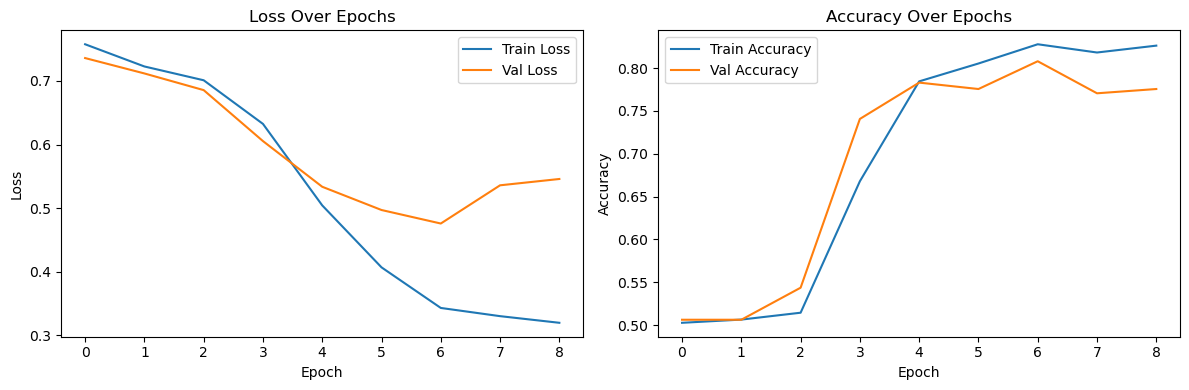

[INFO] Figure saved to figures/training_curves.png


In [795]:
# Plot training curves
# history_dict is populated whether training ran this session or was
# loaded from output/history.pkl. Curves are available on every run.

if history_dict is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_dict['loss'],     label='Train Loss')
    axes[0].plot(history_dict['val_loss'], label='Val Loss')
    axes[0].set_title('Loss Over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history_dict['accuracy'],     label='Train Accuracy')
    axes[1].plot(history_dict['val_accuracy'], label='Val Accuracy')
    axes[1].set_title('Accuracy Over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('figures/training_curves.png', dpi=150)
    plt.show()
    print('[INFO] Figure saved to figures/training_curves.png')

else:
    print('[INFO] No training history available.')
    print('[INFO] Delete output/best_model.keras and rerun to retrain.')


In [796]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print('=== Test Set Evaluation ===')
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

=== Test Set Evaluation ===
Test Loss:     0.5328
Test Accuracy: 0.7756 (77.56%)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
=== Classification Report ===
              precision    recall  f1-score   support

    Negative       0.75      0.81      0.78       198
    Positive       0.80      0.74      0.77       203

    accuracy                           0.78       401
   macro avg       0.78      0.78      0.78       401
weighted avg       0.78      0.78      0.78       401



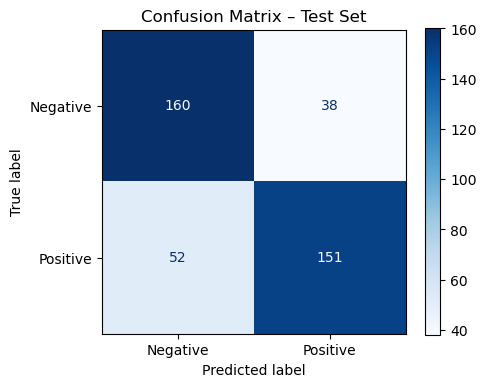

[INFO] Figure saved to figures/confusion_matrix.png


In [797]:
# Detailed classification report & confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int).flatten()

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix – Test Set')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=150)
plt.show()
print('[INFO] Figure saved to figures/confusion_matrix.png')

---
## Part E – Ethical Standards
The analysis addresses AI ethical standards in the written report (sections A–E). Key considerations: balanced dataset (500 positive / 500 negative per source), transparent preprocessing pipeline, no personally identifiable information used, reproducible random seeds, and open documentation of model limitations.

---
## References
- Kotzias, D., Denil, M., de Freitas, N., & Smyth, P. (2015). *From group to individual labels using deep features*. KDD 2015. https://dl.acm.org/doi/10.1145/2783258.2783380
- Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.
- TensorFlow Developers. (2024). *TensorFlow* (v2.x). https://www.tensorflow.org
- Bird, S., Klein, E., & Loper, E. (2009). *Natural language processing with Python*. O'Reilly Media. https://www.nltk.org/book/
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://scikit-learn.org